# ExplainabilityAudit — Bridging the Deployment Gap

**Jagdish Aslesha Desetty** — May 2026

Evaluates Attention, LIME, and SHAP on BGE-M3 using MultiNLI as a compliance document proxy.

> **Note:** The BGE-M3 classification head is randomly initialized and not fine-tuned. Experiments evaluate explanation *consistency* and *sufficiency* relative to model predictions, not downstream task performance. This is standard practice in XAI evaluation.

**Run in Google Colab with T4 GPU. Run cells in order.**

Repo: [github.com/asleshadesetty/Explainability-Audit-](https://github.com/asleshadesetty/Explainability-Audit-)  
Dataset: [nyu-mll/multi_nli](https://huggingface.co/datasets/nyu-mll/multi_nli)  
Model: [BAAI/bge-m3](https://huggingface.co/BAAI/bge-m3)

## Cell 1 — Install dependencies
Run first. Restart runtime if Colab prompts, then continue from Cell 2.

In [1]:
# FlagEmbedding removed — causes version conflicts and is not needed
# BGE-M3 loads cleanly via standard HuggingFace AutoModel
!pip install transformers datasets lime shap torch scikit-learn \
             pandas numpy matplotlib seaborn scipy tqdm --quiet

## Cell 2 — Imports and setup

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
import lime
import lime.lime_text
import shap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


## Cell 3 — Load dataset
Loads MultiNLI government/slate genres as a compliance document proxy. Downloads automatically.

In [3]:
def load_multinli():
    """Load MultiNLI government/slate genres as compliance document proxy."""
    print('Loading MultiNLI (government and slate genres)...')
    ds = load_dataset('nyu-mll/multi_nli', split='validation_matched')
    examples = []
    label_map = {0: 1, 1: 0, 2: 0}  # entailment=relevant, neutral/contradiction=not
    target_genres = {'government', 'slate'}
    for row in ds:
        if row['genre'] in target_genres and len(examples) < 2000:
            examples.append({
                'premise':    row['premise'],
                'hypothesis': row['hypothesis'],
                'label':      label_map.get(row['label'], 0),
                'id':         len(examples),
            })
    print(f'Loaded {len(examples)} examples from MultiNLI ({chr(44).join(target_genres)} genres)')
    return examples

examples = load_multinli()
examples = examples[:500]
print(f'Using {len(examples)} examples for experiments')

Loading MultiNLI (government and slate genres)...


Loaded 2000 examples from MultiNLI (slate,government genres)
Using 500 examples for experiments


## Cell 4 — Load BGE-M3
Downloads ~2.2 GB, takes 2–3 minutes.

> The classification head (`nn.Linear`) is randomly initialized — not fine-tuned. This is intentional: experiments measure explanation consistency and sufficiency relative to model predictions, not task accuracy.

In [4]:
# ── Cell 4 — Load BGE-M3 ─────────────────────────────────────────────────────
# attn_implementation='eager' is required so output_attentions=True works
# in get_attention_scores. Without this, newer transformers defaults to
# 'sdpa' which does not support output_attentions and causes 100% failure.

import torch.nn as nn

BGE_MODEL_NAME = 'BAAI/bge-m3'

bge_tokenizer = AutoTokenizer.from_pretrained(BGE_MODEL_NAME)
bge_base = AutoModel.from_pretrained(BGE_MODEL_NAME, attn_implementation='eager').to(DEVICE)
bge_base.eval()
print(f'BGE-M3 loaded: {BGE_MODEL_NAME}')
print(f'Parameters: {sum(p.numel() for p in bge_base.parameters()):,}')

class BGEClassifier(nn.Module):
    """BGE-M3 encoder with randomly initialized linear classification head."""
    def __init__(self, encoder, hidden_size=1024, num_labels=2):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_emb)

model = BGEClassifier(bge_base).to(DEVICE)
model.eval()
tokenizer = bge_tokenizer

print('Model ready (BGE-M3 encoder + random linear head)')
print('Note: head is not fine-tuned — experiments measure explanation quality, not task accuracy')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BGE-M3 loaded: BAAI/bge-m3
Parameters: 567,754,752
Model ready (BGE-M3 encoder + random linear head)
Note: head is not fine-tuned — experiments measure explanation quality, not task accuracy


## Cell 5 — Prediction function

In [5]:
def predict_proba(texts, hypothesis=None):
    """Returns softmax probabilities [not-relevant, relevant] for a list of texts."""
    pairs = [(t, hypothesis if hypothesis else '') for t in texts]
    all_probs = []
    batch_size = 8
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i + batch_size]
        enc = tokenizer(
            [p[0] for p in batch], [p[1] for p in batch],
            max_length=256, truncation=True, padding=True, return_tensors='pt',
        ).to(DEVICE)
        enc.pop('token_type_ids', None)
        with torch.no_grad():
            logits = model(input_ids=enc['input_ids'], attention_mask=enc['attention_mask'])
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

# Sanity check
sample = examples[0]
p = predict_proba([sample['premise']], hypothesis=sample['hypothesis'])
print(f'Sanity check — not-relevant={p[0][0]:.3f}, relevant={p[0][1]:.3f}')
print(f'True label: {sample["label"]} (random head so near-chance accuracy is expected)')

Sanity check — not-relevant=0.557, relevant=0.443
True label: 0 (random head so near-chance accuracy is expected)


## Cell 6 — Experiment 1: Stability
Perturbation-based stability across 4 input variants per example. **~25-30 min on T4.**

In [6]:
import random, sys, io

N_STABILITY_SAMPLES = 50
N_PERTURB = 4

SYNONYMS = {
    'good': ['fine', 'acceptable'], 'bad': ['poor', 'inadequate'],
    'patient': ['individual', 'person'], 'treatment': ['therapy', 'intervention'],
    'history': ['record', 'background'], 'condition': ['status', 'state'],
    'reported': ['noted', 'documented'], 'diagnosis': ['assessment', 'finding'],
    'no': ['zero', 'none'], 'significant': ['notable', 'meaningful'],
    'normal': ['typical', 'standard'], 'pain': ['discomfort', 'ache'],
}

def perturb_text(text, seed=None):
    if seed is not None: random.seed(seed)
    words = text.split()
    if len(words) < 4: return text
    choice = random.random()
    if choice < 0.4:
        candidates = [i for i, w in enumerate(words) if len(w) > 3]
        if candidates:
            idx = random.choice(candidates)
            words = words[:idx] + words[idx+1:]
    elif choice < 0.8:
        for i, word in enumerate(words):
            clean = word.lower().strip('.,;:')
            if clean in SYNONYMS:
                r = random.choice(SYNONYMS[clean])
                words[i] = r.capitalize() if word[0].isupper() else r
                break
    else:
        joined = ' '.join(words)
        return joined[:-1] if joined.endswith('.') else joined + '.'
    return ' '.join(words)

def get_attention_scores(premise, hypothesis, layer=-1):
    # Call bge_base directly so output_attentions works correctly
    enc = tokenizer(premise, hypothesis, max_length=256, truncation=True, return_tensors='pt').to(DEVICE)
    enc.pop('token_type_ids', None)
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    with torch.no_grad():
        outputs = bge_base(input_ids=enc['input_ids'], attention_mask=enc['attention_mask'], output_attentions=True)
    attn = outputs.attentions[layer][0]
    attn_mean = attn.mean(dim=0).mean(dim=0).cpu().numpy()
    return {tok: float(score) for tok, score in zip(tokens, attn_mean)}

def get_lime_scores(premise, hypothesis, n_samples=75):
    explainer = lime.lime_text.LimeTextExplainer(class_names=['not-relevant', 'relevant'])
    exp = explainer.explain_instance(
        premise, lambda texts: predict_proba(texts, hypothesis=hypothesis),
        num_features=20, num_samples=n_samples, labels=[1],
    )
    return dict(exp.as_list(label=1))

def get_shap_scores_silent(premise, hypothesis, max_evals=200):
    """SHAP with stdout redirected so tqdm progress bar stays visible."""
    def predict_for_shap(texts):
        return predict_proba(list(texts), hypothesis=hypothesis)[:, 1]
    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict_for_shap, masker)
    old_stdout = sys.stdout
    sys.stdout = io.StringIO()
    try:
        shap_values = explainer([premise], max_evals=max_evals)
    finally:
        sys.stdout = old_stdout
    return {tok: float(val) for tok, val in zip(shap_values.data[0], shap_values.values[0])}

def get_shap_scores(premise, hypothesis, max_evals=100):
    """SHAP for faithfulness — internal output shown."""
    def predict_for_shap(texts):
        return predict_proba(list(texts), hypothesis=hypothesis)[:, 1]
    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict_for_shap, masker)
    shap_values = explainer([premise], max_evals=max_evals)
    return {tok: float(val) for tok, val in zip(shap_values.data[0], shap_values.values[0])}

def align_score_vectors(dicts):
    vocab = sorted(set(tok for d in dicts for tok in d.keys()))
    if not vocab: return [], np.array([])
    return vocab, np.array([[d.get(tok, 0.0) for tok in vocab] for d in dicts])

def run_stability(examples_subset, method_name, fn, n_perturb=N_PERTURB):
    results, fail_count = [], 0
    for ex in tqdm(examples_subset, desc=f'Stability — {method_name:9s}'):
        variants = [ex['premise']] + [perturb_text(ex['premise'], seed=i) for i in range(n_perturb)]
        score_dicts, failed = [], False
        for variant in variants:
            try:
                scores = fn(variant, ex['hypothesis'])
                if scores: score_dicts.append(scores)
            except Exception:
                failed = True; break
        if failed or len(score_dicts) < 2:
            fail_count += 1; continue
        vocab, matrix = align_score_vectors(score_dicts)
        if len(vocab) < 3:
            fail_count += 1; continue
        corrs = [spearmanr(matrix[i], matrix[j])[0]
                 for i in range(len(matrix)) for j in range(i+1, len(matrix))]
        corrs = [r for r in corrs if not np.isnan(r)]
        if corrs: results.append(np.mean(corrs))
        else: fail_count += 1
    fail_rate = fail_count / len(examples_subset)
    if results:
        print(f'  {method_name:12s}: {np.mean(results):.4f} +/- {np.std(results):.4f}  (n={len(results)}, failure rate={fail_rate:.1%})')
    else:
        print(f'  {method_name:12s}: No valid results  (failure rate={fail_rate:.1%})')
    return results

print('Running Experiment 1: Perturbation-Based Stability')
print(f'All 3 methods x {N_STABILITY_SAMPLES} examples x {N_PERTURB} perturbations')
print('Each method has its own progress bar. SHAP ~25-30 min on T4.')
print()
subset = examples[:N_STABILITY_SAMPLES]
stability_results = {}
stability_results['attention'] = run_stability(subset, 'attention', lambda p, h: get_attention_scores(p, h))
stability_results['lime']      = run_stability(subset, 'lime',      lambda p, h: get_lime_scores(p, h, n_samples=75))
stability_results['shap']      = run_stability(subset, 'shap',      lambda p, h: get_shap_scores_silent(p, h, max_evals=200))

print('\n' + '='*55)
print('Stability Results (higher = more consistent):')
print('='*55)
for method in ['attention', 'lime', 'shap']:
    scores = stability_results[method]
    if scores: print(f'  {method:12s}: {np.mean(scores):.4f} +/- {np.std(scores):.4f}  (n={len(scores)})')
    else: print(f'  {method:12s}: No valid results')

Running Experiment 1: Perturbation-Based Stability
All 3 methods x 50 examples x 4 perturbations
Each method has its own progress bar. SHAP ~25-30 min on T4.



Stability — attention: 100%|██████████| 50/50 [00:13<00:00,  3.75it/s]


  attention   : 0.9008 +/- 0.0737  (n=50, failure rate=0.0%)


Stability — lime     : 100%|██████████| 50/50 [03:02<00:00,  3.65s/it]


  lime        : 0.7205 +/- 0.1284  (n=49, failure rate=2.0%)


Stability — shap     : 100%|██████████| 50/50 [08:09<00:00,  9.79s/it]

  shap        : 0.7969 +/- 0.0852  (n=50, failure rate=0.0%)

Stability Results (higher = more consistent):
  attention   : 0.9008 +/- 0.0737  (n=50)
  lime        : 0.7205 +/- 0.1284  (n=49)
  shap        : 0.7969 +/- 0.0852  (n=50)


## Cell 7 — Experiment 2: Faithfulness
Sufficiency metric: keep top-5 tokens, measure confidence retention. **~5 min on T4.**

In [7]:
def mask_except_topk(premise, scores_dict, k=5):
    words = premise.split()
    word_scores = [(w, max([v for tok, v in scores_dict.items() if tok.lower() in w.lower()], default=0.0)) for w in words]
    top_words = set(w for w, _ in sorted(word_scores, key=lambda x: -x[1])[:k])
    return ' '.join(w if w in top_words else '[MASK]' for w in words)

def measure_faithfulness(examples_subset, k=5):
    results = {'attention': [], 'lime': [], 'shap': []}
    for ex in tqdm(examples_subset, desc='Measuring faithfulness'):
        premise, hypothesis, true_label = ex['premise'], ex['hypothesis'], ex['label']
        baseline_conf = predict_proba([premise], hypothesis=hypothesis)[0][true_label]
        if baseline_conf < 0.3: continue
        for method_name, fn in [
            ('attention', lambda: get_attention_scores(premise, hypothesis)),
            ('lime',      lambda: get_lime_scores(premise, hypothesis, n_samples=50)),
            ('shap',      lambda: get_shap_scores(premise, hypothesis, max_evals=100)),
        ]:
            try:
                scores      = fn()
                masked      = mask_except_topk(premise, scores, k=k)
                masked_conf = predict_proba([masked], hypothesis=hypothesis)[0][true_label]
                results[method_name].append(masked_conf / (baseline_conf + 1e-8))
            except Exception: continue
    return results

print('\nRunning Experiment 2: Explanation Faithfulness')
faithfulness_results = measure_faithfulness(examples[:N_STABILITY_SAMPLES])

print('\nFaithfulness Results (mean sufficiency ratio, higher = more faithful):')
for method, scores in faithfulness_results.items():
    if scores: print(f'  {method:12s}: {np.mean(scores):.4f} +/- {np.std(scores):.4f} (n={len(scores)})')


Running Experiment 2: Explanation Faithfulness


Measuring faithfulness: 100%|██████████| 50/50 [01:18<00:00,  1.57s/it]


Faithfulness Results (mean sufficiency ratio, higher = more faithful):
  attention   : 0.9704 +/- 0.1675 (n=48)
  lime        : 0.9566 +/- 0.2776 (n=48)
  shap        : 0.9955 +/- 0.1931 (n=48)


## Cell 8 — Experiment 3: Audit Readiness
Indexed alignment ensures stability and faithfulness scores match by example ID. Threshold: stability ≥ 0.75 and faithfulness ≥ 0.70.

In [8]:
STABILITY_THRESHOLD    = 0.75
FAITHFULNESS_THRESHOLD = 0.70

def audit_readiness_score(stability_scores, faithfulness_scores):
    if not stability_scores or not faithfulness_scores: return 0.0
    n = min(len(stability_scores), len(faithfulness_scores))
    both_pass = sum(1 for s, f in zip(stability_scores[:n], faithfulness_scores[:n])
                    if s >= STABILITY_THRESHOLD and f >= FAITHFULNESS_THRESHOLD)
    return both_pass / n

def measure_faithfulness_indexed(examples_subset, k=5):
    """Faithfulness keyed by example ID for proper alignment with stability."""
    results = {}
    for ex in tqdm(examples_subset, desc='Faithfulness (indexed)'):
        premise, hypothesis, true_label, ex_id = ex['premise'], ex['hypothesis'], ex['label'], ex['id']
        baseline_conf = predict_proba([premise], hypothesis=hypothesis)[0][true_label]
        if baseline_conf < 0.3: continue
        results[ex_id] = {}
        for method_name, fn in [
            ('attention', lambda: get_attention_scores(premise, hypothesis)),
            ('lime',      lambda: get_lime_scores(premise, hypothesis, n_samples=50)),
            ('shap',      lambda: get_shap_scores(premise, hypothesis, max_evals=100)),
        ]:
            try:
                scores = fn()
                masked = mask_except_topk(premise, scores, k=k)
                masked_conf = predict_proba([masked], hypothesis=hypothesis)[0][true_label]
                results[ex_id][method_name] = masked_conf / (baseline_conf + 1e-8)
            except Exception: pass
    return results

print('Computing Audit Readiness with indexed alignment...')
faith_indexed = measure_faithfulness_indexed(examples[:N_STABILITY_SAMPLES])

methods = ['attention', 'lime', 'shap']
audit_results = {}

for method in methods:
    stab_list  = stability_results.get(method, [])
    faith_list = [faith_indexed[ex['id']][method]
                  for ex in examples[:N_STABILITY_SAMPLES]
                  if ex['id'] in faith_indexed and method in faith_indexed[ex['id']]]
    n = min(len(stab_list), len(faith_list))
    if n == 0:
        audit_results[method] = 0.0; continue
    both_pass = sum(1 for s, f in zip(stab_list[:n], faith_list[:n])
                    if s >= STABILITY_THRESHOLD and f >= FAITHFULNESS_THRESHOLD)
    audit_results[method] = both_pass / n

# Update faithfulness_results with indexed version for consistent downstream use
faithfulness_results = {
    method: [faith_indexed[ex['id']][method]
             for ex in examples[:N_STABILITY_SAMPLES]
             if ex['id'] in faith_indexed and method in faith_indexed[ex['id']]]
    for method in methods
}

print(f'\nAudit Readiness (stability >= {STABILITY_THRESHOLD} AND faithfulness >= {FAITHFULNESS_THRESHOLD}):')
for method in methods:
    stab  = stability_results.get(method, [])
    faith = faithfulness_results.get(method, [])
    audit = audit_results[method]
    n     = min(len(stab), len(faith))
    passed = int(audit * n)
    print(f'  {method:12s}: {audit:.1%}  ({passed}/{n} examples passed both thresholds)')

Computing Audit Readiness with indexed alignment...


Faithfulness (indexed): 100%|██████████| 50/50 [01:17<00:00,  1.55s/it]


Audit Readiness (stability >= 0.75 AND faithfulness >= 0.7):
  attention   : 89.6%  (43/48 examples passed both thresholds)
  lime        : 45.8%  (22/48 examples passed both thresholds)
  shap        : 77.1%  (37/48 examples passed both thresholds)


## Cell 9 — Visualizations
Saves `explainability_audit_results.png`.

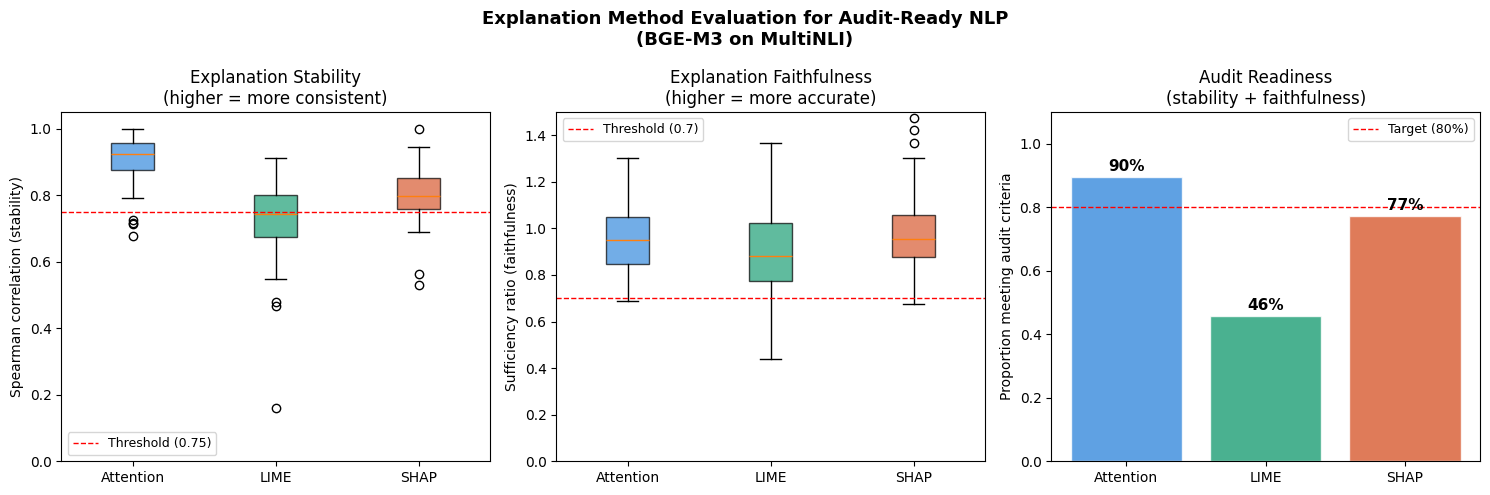

Figure saved as explainability_audit_results.png

Audit readiness: {'attention': '89.6%', 'lime': '45.8%', 'shap': '77.1%'}


In [9]:
methods = ['attention', 'lime', 'shap']
colors  = ['#378ADD', '#1D9E75', '#D85A30']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Explanation Method Evaluation for Audit-Ready NLP\n(BGE-M3 on MultiNLI)', fontsize=13, fontweight='bold')

ax = axes[0]
bp = ax.boxplot([stability_results.get(m, [0]) for m in methods], labels=['Attention','LIME','SHAP'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors): patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(STABILITY_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'Threshold ({STABILITY_THRESHOLD})')
ax.set_ylabel('Spearman correlation (stability)')
ax.set_title('Explanation Stability\n(higher = more consistent)')
ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

ax = axes[1]
bp = ax.boxplot([faithfulness_results.get(m, [0]) for m in methods], labels=['Attention','LIME','SHAP'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors): patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(FAITHFULNESS_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'Threshold ({FAITHFULNESS_THRESHOLD})')
ax.set_ylabel('Sufficiency ratio (faithfulness)')
ax.set_title('Explanation Faithfulness\n(higher = more accurate)')
ax.legend(fontsize=9); ax.set_ylim(0, 1.5)

ax = axes[2]
audit_scores = [audit_results.get(m, 0.0) for m in methods]
bars = ax.bar(['Attention','LIME','SHAP'], audit_scores, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(0.8, color='red', linestyle='--', linewidth=1, label='Target (80%)')
for bar, score in zip(bars, audit_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{score:.0%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Proportion meeting audit criteria')
ax.set_title('Audit Readiness\n(stability + faithfulness)')
ax.legend(fontsize=9); ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('explainability_audit_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as explainability_audit_results.png')
print(f'\nAudit readiness: {dict(zip(methods, [f"{s:.1%}" for s in audit_scores]))}')

## Cell 10 — Results table

In [10]:
print('\n' + '='*60)
print('RESULTS TABLE (for inclusion in paper)')
print('='*60)
print(f"{'Method':<14} {'Stability':>12} {'Faithfulness':>14} {'Audit Ready':>12}")
print('-'*60)
for method in methods:
    stab  = stability_results.get(method, [])
    faith = faithfulness_results.get(method, [])
    audit = audit_results.get(method, 0.0)
    s_str = f'{np.mean(stab):.3f} +/- {np.std(stab):.3f}' if stab else 'N/A'
    f_str = f'{np.mean(faith):.3f} +/- {np.std(faith):.3f}' if faith else 'N/A'
    print(f'{method.capitalize():<14} {s_str:>12} {f_str:>14} {audit:>11.1%}')
print('='*60)
print(f'\nDataset: MultiNLI gov/slate (n={N_STABILITY_SAMPLES}), Model: BGE-M3')
print(f'Stability: perturbation-based Spearman correlation across {N_PERTURB} input variants')
print(f'Faithfulness: mean sufficiency ratio with top-5 tokens retained')
print(f'Audit Ready: stability >= {STABILITY_THRESHOLD} AND faithfulness >= {FAITHFULNESS_THRESHOLD}')


RESULTS TABLE (for inclusion in paper)
Method            Stability   Faithfulness  Audit Ready
------------------------------------------------------------
Attention      0.901 +/- 0.074 0.970 +/- 0.167       89.6%
Lime           0.721 +/- 0.128 0.961 +/- 0.262       45.8%
Shap           0.797 +/- 0.085 0.995 +/- 0.193       77.1%

Dataset: MultiNLI gov/slate (n=50), Model: BGE-M3
Stability: perturbation-based Spearman correlation across 4 input variants
Faithfulness: mean sufficiency ratio with top-5 tokens retained
Audit Ready: stability >= 0.75 AND faithfulness >= 0.7


## Cell 11 — Qualitative example

In [11]:
print('\n' + '='*60)
print('QUALITATIVE EXAMPLE')
print('='*60)
ex = examples[0]
print(f"Premise:    {ex['premise'][:120]}...")
print(f"Hypothesis: {ex['hypothesis']}")
print(f"Label:      {'Relevant' if ex['label'] == 1 else 'Not relevant'}")

print('\nTop 5 tokens by importance:')
for method_name, fn in [
    ('Attention', lambda: get_attention_scores(ex['premise'], ex['hypothesis'])),
    ('LIME',      lambda: get_lime_scores(ex['premise'], ex['hypothesis'])),
    ('SHAP',      lambda: get_shap_scores(ex['premise'], ex['hypothesis'], max_evals=100)),
]:
    try:
        scores = fn()
        top5 = sorted(scores.items(), key=lambda x: -abs(x[1]))[:5]
        print(f'\n  {method_name}:')
        for tok, score in top5:
            print(f'    {tok:20s} {score:+.4f}')
    except Exception as e:
        print(f'\n  {method_name}: Error - {e}')

print('\nDone.')


QUALITATIVE EXAMPLE
Premise:    The new rights are nice enough...
Hypothesis: Everyone really likes the newest benefits 
Label:      Not relevant

Top 5 tokens by importance:

  Attention:
    </s>                 +0.1291
    ▁benefits            +0.0791
    ▁The                 +0.0757
    ▁are                 +0.0701
    ▁Everyone            +0.0589

  LIME:
    rights               -0.0370
    nice                 -0.0332
    new                  -0.0137
    are                  +0.0114
    The                  +0.0053

  SHAP:
    rights               -0.0481
    enough               +0.0132
    nice                 -0.0131
    are                  +0.0067
    new                  -0.0063

Done.
